In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv('Task3.csv')

### Basic Data Exploration

In [ ]:

display(df.head())

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [ ]:

display(df.sample(5))

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
458,3115000,3850,3,1,2,yes,no,no,no,no,0,no,unfurnished
12,9310000,6550,4,2,2,yes,no,no,no,yes,1,yes,semi-furnished
101,6230000,5500,3,1,3,yes,no,no,no,no,1,yes,unfurnished
182,5145000,3410,3,1,2,no,no,no,no,yes,0,no,semi-furnished
38,7962500,6000,3,1,4,yes,yes,no,no,yes,2,no,unfurnished


In [ ]:

display(df.tail())

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished
544,1750000,3850,3,1,2,yes,no,no,no,no,0,no,unfurnished


In [ ]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [ ]:

display(df.isnull().sum())

,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


In [ ]:

display(df.dtypes)

,0
price,int64
area,int64
bedrooms,int64
bathrooms,int64
stories,int64
mainroad,object
guestroom,object
basement,object
hotwaterheating,object
airconditioning,object


In [ ]:

display(df.describe())

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


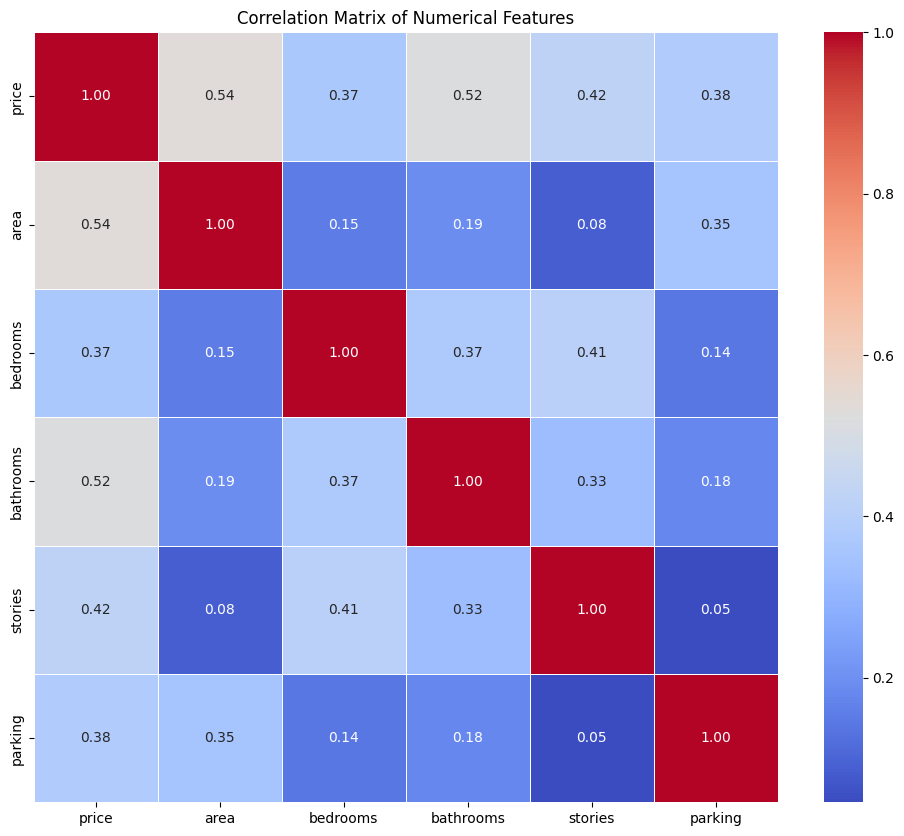

In [ ]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
corr_matrix = df[numerical_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

/tmp/ipykernel_2317/809889343.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=house_counts.index.astype(str), y=house_counts.values, palette='viridis')


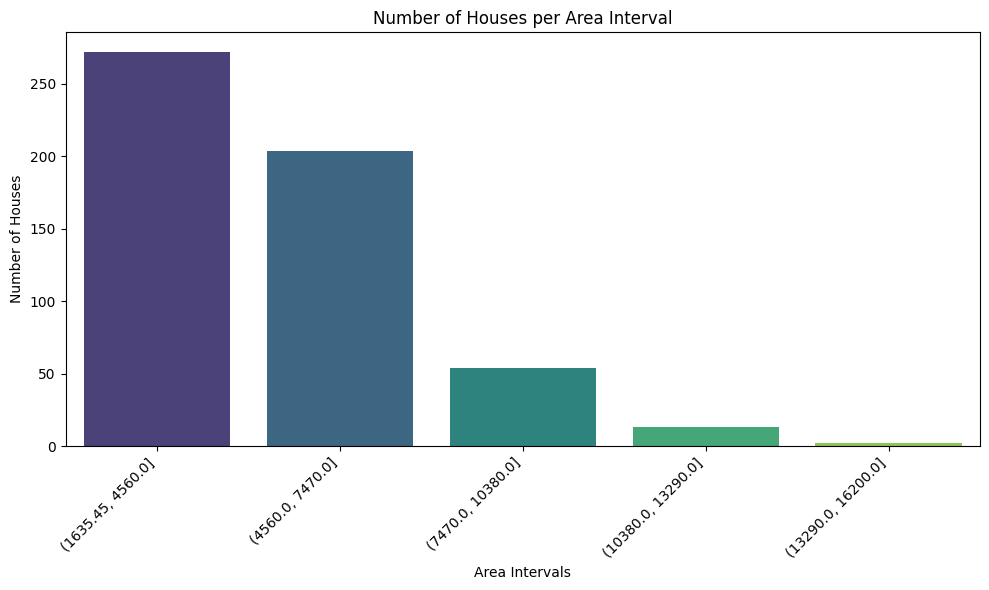

,count
area_bins,
"(1635.45, 4560.0]",272
"(4560.0, 7470.0]",204
"(7470.0, 10380.0]",54
"(10380.0, 13290.0]",13
"(13290.0, 16200.0]",2


In [ ]:
import numpy as np

df['area_bins'] = pd.cut(df['area'], bins=5)


house_counts = df['area_bins'].value_counts().sort_index()


plt.figure(figsize=(10, 6))
sns.barplot(x=house_counts.index.astype(str), y=house_counts.values, palette='viridis')
plt.xlabel('Area Intervals')
plt.ylabel('Number of Houses')
plt.title('Number of Houses per Area Interval')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

display(house_counts)

### Exploring Factors Affecting House Prices

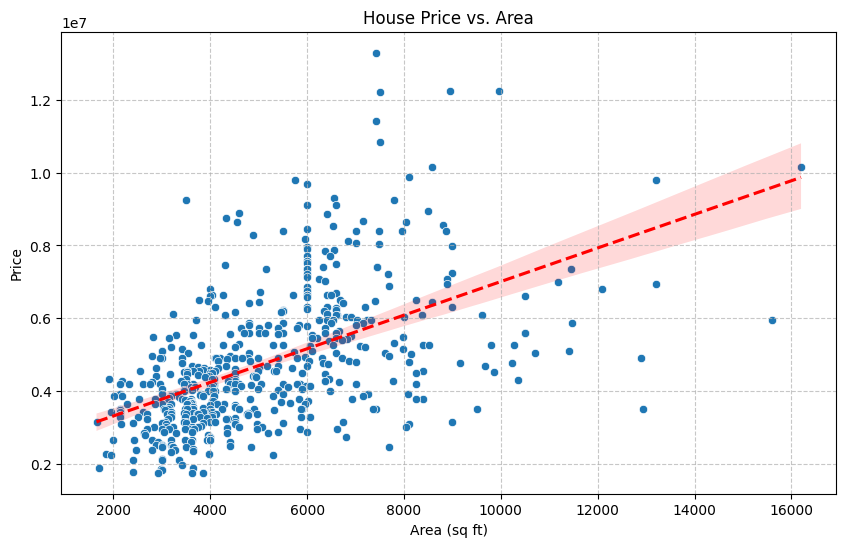

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='area', y='price', data=df)
sns.regplot(x='area', y='price', data=df, scatter=False, color='red', line_kws={'linestyle': '--'})
plt.title('House Price vs. Area')
plt.xlabel('Area (sq ft)')
plt.ylabel('Price')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

This scatter plot clearly shows a positive correlation between the area of a house and its price, as expected. Larger houses generally command higher prices. The regression line further emphasizes this linear trend.

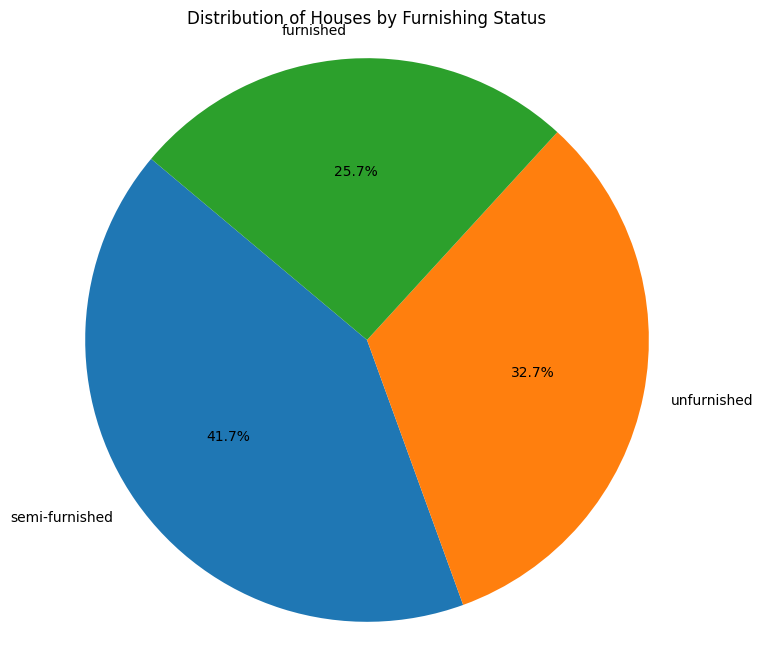

In [ ]:
furnishing_counts = df['furnishingstatus'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(furnishing_counts, labels=furnishing_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Houses by Furnishing Status')
plt.axis('equal')
plt.show()

In [ ]:
average_price_by_furnishing = df.groupby('furnishingstatus')['price'].mean().reset_index()
display(average_price_by_furnishing)

,furnishingstatus,price
0,furnished,5.495696e+06
1,semi-furnished,4.907524e+06
2,unfurnished,4.013831e+06


/tmp/ipykernel_2317/1771501080.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='furnishingstatus', y='price', data=average_price_by_furnishing, palette='viridis')


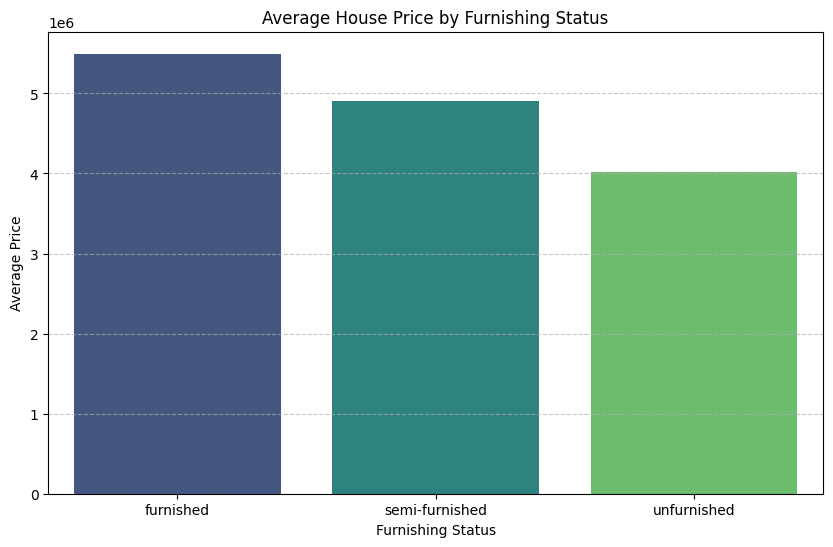

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x='furnishingstatus', y='price', data=average_price_by_furnishing, palette='viridis')
plt.title('Average House Price by Furnishing Status')
plt.xlabel('Furnishing Status')
plt.ylabel('Average Price')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

/tmp/ipykernel_2317/2828456924.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='bedrooms', y='price', data=df, palette='coolwarm')


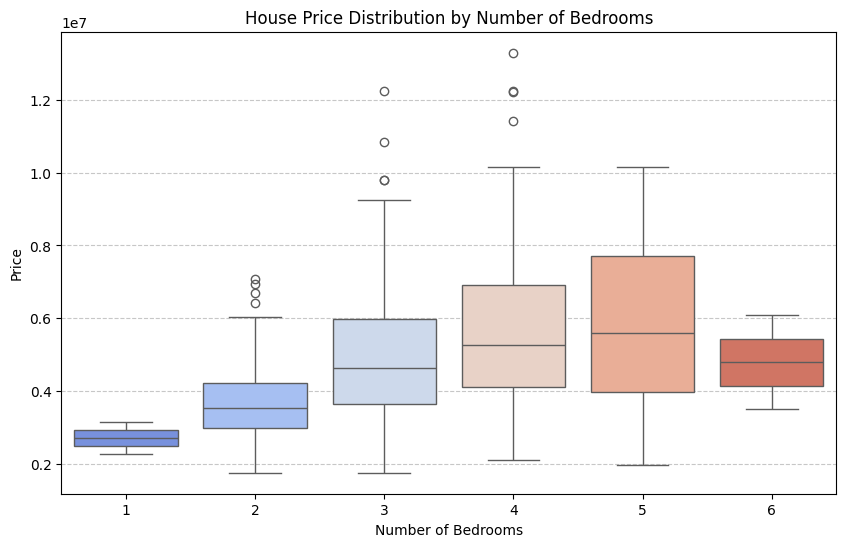

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='bedrooms', y='price', data=df, palette='coolwarm')
plt.title('House Price Distribution by Number of Bedrooms')
plt.xlabel('Number of Bedrooms')
plt.ylabel('Price')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()